In [2]:
import numpy as np
import torch
import os
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Data Loader**

In [4]:
class XrayDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for label in ['caries', 'no_caries']:
            folder = os.path.join(data_dir, label)
            for img_name in os.listdir(folder):
                self.image_paths.append(os.path.join(folder, img_name))
                self.labels.append(0 if label == 'caries' else 1)  # 0 for caries, 1 for no caries

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('L')
        except Exception as e:
            # Handle exceptions or skip corrupted images
            print(f"Error loading image {img_path}: {e}")
            return None, None

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

def data_loader(data_dir,
                batch_size,
                random_seed=42,
                valid_size=0.1,
                test_size=0.1,
                shuffle=True):

    normalize = transforms.Normalize(
        mean=[0.48651000273298833],
        std=[0.2391280073626813],
    )

    # Define transforms
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        # transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
        # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        normalize,
    ])

    # Load the full dataset
    full_dataset = XrayDataset(data_dir=data_dir, transform=transform)

    num_samples = len(full_dataset)
    indices = list(range(num_samples))
    split = int(np.floor(valid_size * num_samples))
    test_split = int(np.floor(test_size * num_samples))

    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    train_idx, valid_idx, test_idx = indices[test_split + split:], indices[test_split:test_split + split], indices[:test_split]

    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)
    test_sampler = SubsetRandomSampler(test_idx)

    train_loader = DataLoader(
        full_dataset, batch_size=batch_size, sampler=train_sampler
    )

    valid_loader = DataLoader(
        full_dataset, batch_size=batch_size, sampler=valid_sampler
    )

    test_loader = DataLoader(
        full_dataset, batch_size=batch_size, sampler=test_sampler
    )

    return train_loader, valid_loader, test_loader

# Load datasets
train_loader, valid_loader, test_loader = data_loader(data_dir='/content/drive/MyDrive/Colab Notebooks/Caries Dataset/Untitled folder',
                                                     batch_size=16,
                                                     valid_size=0.1,
                                                     test_size=0.1)

## **Bottelneck + ResNet**

In [5]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        # Bottleneck layers
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=2, input_channels=1):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer0 = self._make_layer(block, 64, layers[0])
        self.layer1 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer2 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer3 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# Create the ResNet-50 model
model = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=2, input_channels=1).to(device)


In [6]:
from torchsummary import summary

# Create the ResNet-50 model
model = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=2, input_channels=1).to(device)

# Get the summary of the model
summary(model, (1, 256, 256))  # Assuming input size is (1, 224, 224) for grayscale images

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           3,136
       BatchNorm2d-2         [-1, 64, 128, 128]             128
              ReLU-3         [-1, 64, 128, 128]               0
         MaxPool2d-4           [-1, 64, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]           4,096
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
            Conv2d-8           [-1, 64, 64, 64]          36,864
       BatchNorm2d-9           [-1, 64, 64, 64]             128
             ReLU-10           [-1, 64, 64, 64]               0
           Conv2d-11          [-1, 256, 64, 64]          16,384
      BatchNorm2d-12          [-1, 256, 64, 64]             512
           Conv2d-13          [-1, 256, 64, 64]          16,384
      BatchNorm2d-14          [-1, 256,

### Model Visualization

In [ ]:
# from torch.utils.tensorboard import SummaryWriter

# # Initialize TensorBoard writer
# writer = SummaryWriter('/content/drive/MyDrive/Colab Notebooks/resnet50_experiment')

# # Create a sample input tensor
# x = torch.randn(1, 1, 512, 512).to(device)

# # Add the model graph to TensorBoard
# writer.add_graph(model, x)
# writer.close()

## Setting **Hyperparamters**

In [7]:
# Update number of classes for binary classification
num_classes = 2
learning_rate = 0.001

# Instantiate the ResNet model with adjusted number of classes
model = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes, input_channels=1).to(device)  # input_channels=1 for grayscale images

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=0.001, momentum=0.9)

# Train the model
total_step = len(train_loader)

# New Training on 2760 images

In [ ]:
# import torch
# import gc

# def train(model, train_loader, criterion, optimizer, device):
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0

#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)

#         # Forward pass
#         outputs = model(images)
#         loss = criterion(outputs, labels)

#         # Backward pass and optimize
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()

#         # Clear cache and memory
#         del images, labels, outputs
#         torch.cuda.empty_cache()
#         gc.collect()

#     epoch_loss = running_loss / len(train_loader)
#     epoch_accuracy = 100 * correct / total
#     return epoch_loss, epoch_accuracy


# def validate(model, valid_loader, criterion, device):
#     model.eval()
#     running_loss = 0.0
#     total = 0
#     correct = 0

#     with torch.no_grad():
#         for images, labels in valid_loader:
#             images, labels = images.to(device), labels.to(device)

#             # Forward pass
#             outputs = model(images)
#             loss = criterion(outputs, labels)

#             running_loss += loss.item()
#             _, predicted = torch.max(outputs.data, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()

#             # Clear cache and memory
#             del images, labels, outputs
#             torch.cuda.empty_cache()
#             gc.collect()

#     epoch_loss = running_loss / len(valid_loader)
#     epoch_accuracy = 100 * correct / total
#     return epoch_loss, epoch_accuracy


# def test(model, test_loader, device):
#     model.eval()
#     total = 0
#     correct = 0

#     with torch.no_grad():
#         for images, labels in test_loader:
#             images, labels = images.to(device), labels.to(device)

#             # Forward pass
#             outputs = model(images)
#             _, predicted = torch.max(outputs.data, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()

#             # Clear cache and memory
#             del images, labels, outputs
#             torch.cuda.empty_cache()
#             gc.collect()

#     test_accuracy = 100 * correct / total
#     return test_accuracy


# # Hyperparameters
# num_epochs = 100
# batch_size = 16
# learning_rate = 0.001
# num_classes = 2  # Changed to 2 for binary classification

# # Model, Loss, Optimizer
# model = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes).to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=0.001, momentum=0.9)

# # Learning Rate Scheduler
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# best_val_accuracy = 0.0

# # Training Loop
# for epoch in range(num_epochs):
#     train_loss, train_accuracy = train(model, train_loader, criterion, optimizer, device)
#     val_loss, val_accuracy = validate(model, valid_loader, criterion, device)

#     # Update learning rate
#     scheduler.step()

#     print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

#     # Save the model checkpoint if it's the best so far
#     if val_accuracy > best_val_accuracy:
#         best_val_accuracy = val_accuracy
#         torch.save(model.state_dict(), 'best_model.pth')

# # Test the model
# test_accuracy = test(model, test_loader, device)
# print(f'Accuracy of the network on the test images: {test_accuracy:.2f}%')


Epoch [1/100], Train Loss: 0.7415, Train Accuracy: 58.3899, Validation Loss: 0.5373, Validation Accuracy: 73.7319


# Evaluate the Model

In [ ]:
# # Function to compute accuracy
# def compute_accuracy(loader, model, device):
#     model.eval()
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for images, labels in loader:
#             images, labels = images.to(device), labels.to(device)
#             outputs = model(images)
#             _, predicted = torch.max(outputs.data, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
#     return 100 * correct / total

# # Compute training accuracy
# train_accuracy = compute_accuracy(train_loader, model, device)
# print(f'Training Accuracy: {train_accuracy:.2f}%')

# # Compute validation accuracy
# val_accuracy = compute_accuracy(valid_loader, model, device)
# print(f'Validation Accuracy: {val_accuracy:.2f}%')

# # Compute test accuracy
# test_accuracy = compute_accuracy(test_loader, model, device)
# print(f'Test Accuracy: {test_accuracy:.2f}%')

## **Training on 920 dataset**

In [8]:
import torch
import gc

def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Clear cache and memory
        del images, labels, outputs
        torch.cuda.empty_cache()
        gc.collect()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    return epoch_loss, epoch_accuracy


def validate(model, valid_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Clear cache and memory
            del images, labels, outputs
            torch.cuda.empty_cache()
            gc.collect()

    epoch_loss = running_loss / len(valid_loader)
    epoch_accuracy = 100 * correct / total
    return epoch_loss, epoch_accuracy


def test(model, test_loader, device):
    model.eval()
    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Clear cache and memory
            del images, labels, outputs
            torch.cuda.empty_cache()
            gc.collect()

    test_accuracy = 100 * correct / total
    return test_accuracy


# Hyperparameters
num_epochs = 100
batch_size = 16
learning_rate = 0.001
num_classes = 2  # Changed to 2 for binary classification

# Model, Loss, Optimizer
model = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=0.001, momentum=0.9)

# Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

best_val_accuracy = 0.0

# Training Loop
for epoch in range(num_epochs):
    train_loss, train_accuracy = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, valid_loader, criterion, device)

    # Update learning rate
    scheduler.step()

    print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    # Save the model checkpoint if it's the best so far
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')

# Test the model
test_accuracy = test(model, test_loader, device)
print(f'Accuracy of the network on the test images: {test_accuracy:.2f}%')


Epoch [1/100], Train Loss: 0.8120, Train Accuracy: 52.1060, Validation Loss: 0.8409, Validation Accuracy: 55.4348


KeyboardInterrupt: 

# **Both graphs in one frame**

In [ ]:
import matplotlib.pyplot as plt

# Function to plot and save combined graphs
def plot_and_save_combined_graphs(epochs, train_losses, val_losses, train_accuracies, val_accuracies):
    # Create a figure and two subplots (one for loss, one for accuracy)
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Loss on the left y-axis
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss', color='tab:blue')
    ax1.plot(range(epochs), train_losses, label='Train Loss', color='blue')
    ax1.plot(range(epochs), val_losses, label='Validation Loss', color='orange')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    # Create a second y-axis for accuracy
    ax2 = ax1.twinx()
    ax2.set_ylabel('Accuracy (%)', color='tab:green')
    ax2.plot(range(epochs), train_accuracies, label='Train Accuracy', color='green')
    ax2.plot(range(epochs), val_accuracies, label='Validation Accuracy', color='red')
    ax2.tick_params(axis='y', labelcolor='tab:green')
    ax2.legend(loc='upper right')

    # Add a title
    plt.title('Training and Validation Loss/Accuracy over Epochs')

    # Save the figure
    plt.savefig('combined_loss_accuracy_graph.png')

# Call this function after training is complete
# epochs = number of epochs
# train_losses, val_losses = lists of training and validation losses
# train_accuracies, val_accuracies = lists of training and validation accuracies
plot_and_save_combined_graphs(epochs, train_losses, val_losses, train_accuracies, val_accuracies)

# **Creating separate Graphs**

In [ ]:
import matplotlib.pyplot as plt

# Function to plot and save graphs
def plot_and_save_graphs(epochs, train_losses, val_losses, train_accuracies, val_accuracies):
    # Plot Loss Graph
    plt.figure(figsize=(10, 5))
    plt.plot(range(epochs), train_losses, label='Train Loss', color='blue')
    plt.plot(range(epochs), val_losses, label='Validation Loss', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.savefig('loss_graph.png')  # Save the loss graph

    # Plot Accuracy Graph
    plt.figure(figsize=(10, 5))
    plt.plot(range(epochs), train_accuracies, label='Train Accuracy', color='green')
    plt.plot(range(epochs), val_accuracies, label='Validation Accuracy', color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy over Epochs')
    plt.legend()
    plt.grid(True)
    plt.savefig('accuracy_graph.png')  # Save the accuracy graph

# Call this function after training is complete
# epochs = number of epochs
# train_losses, val_losses = lists of training and validation losses
# train_accuracies, val_accuracies = lists of training and validation accuracies
plot_and_save_graphs(epochs, train_losses, val_losses, train_accuracies, val_accuracies)

## **Evaluate the model**

In [ ]:
# Function to compute accuracy
def compute_accuracy(loader, model, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Compute training accuracy
train_accuracy = compute_accuracy(train_loader, model, device)
print(f'Training Accuracy: {train_accuracy:.2f}%')

# Compute validation accuracy
val_accuracy = compute_accuracy(valid_loader, model, device)
print(f'Validation Accuracy: {val_accuracy:.2f}%')

# Compute test accuracy
test_accuracy = compute_accuracy(test_loader, model, device)
print(f'Test Accuracy: {test_accuracy:.2f}%')

# **Save the Model**

In [ ]:
# Save the model checkpoint
torch.save(model.state_dict(), '/content/drive/MyDrive/resnet50_caries_classification.pth')
print("Model saved successfully!")

Model saved successfully!


# **Testing on unseen images**

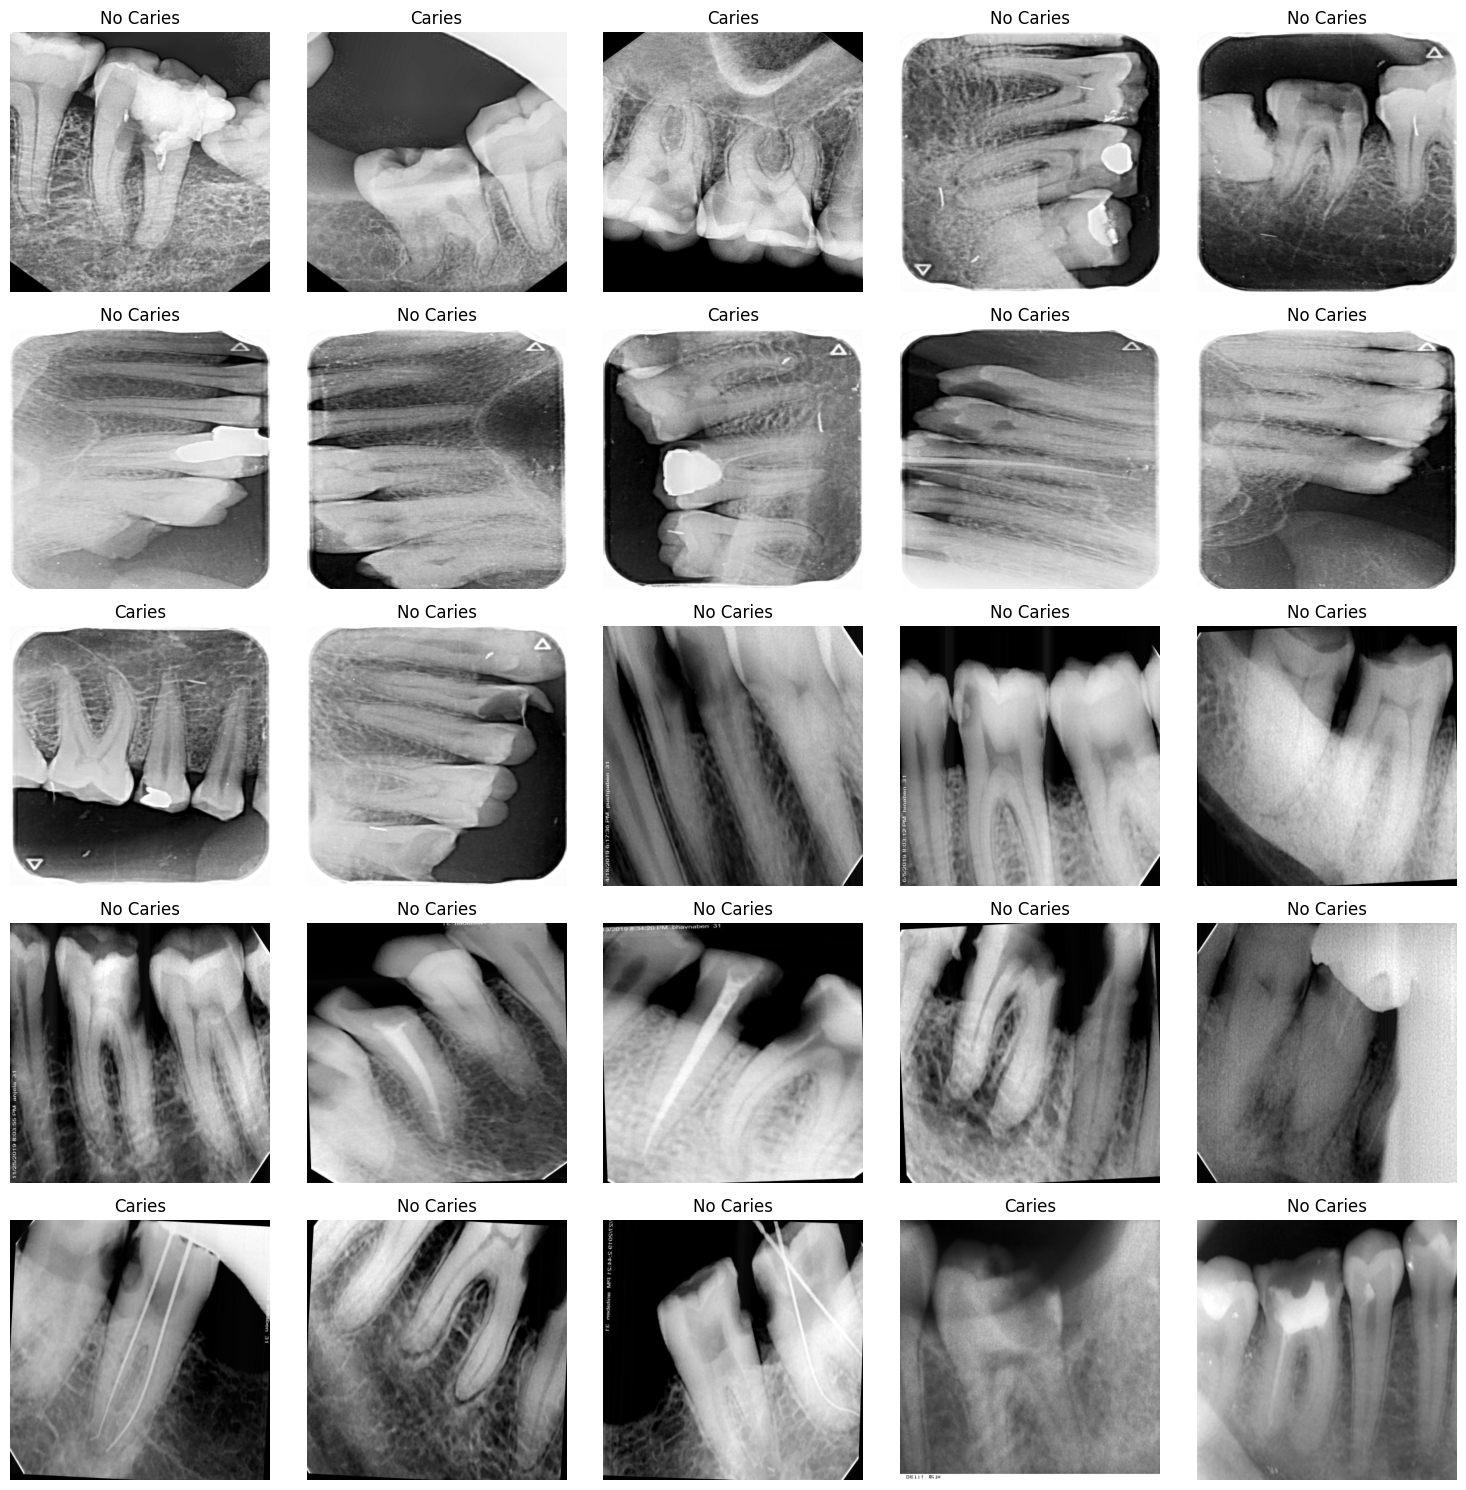

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

def test_on_folder(folder_path, model, device):
    # Apply the same transformations as for the training images
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914], std=[0.2023])
    ])

    model.eval()  # Set model to evaluation mode
    predictions = []  # List to store predictions

    fig, axes = plt.subplots(5, 5, figsize=(15, 15))  # Adjust the size as needed
    axes = axes.flatten()  # Flatten the 2D array to 1D for easier indexing
    img_count = 0

    with torch.no_grad():
        for filename in os.listdir(folder_path):
            if filename.endswith(('.png', '.jpg', '.jpeg')):  # Check for image files
                image_path = os.path.join(folder_path, filename)
                image = Image.open(image_path).convert('L')
                image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
                image_tensor = image_tensor.to(device)

                output = model(image_tensor)
                _, predicted = torch.max(output, 1)
                class_name = 'Caries' if predicted.item() == 1 else 'No Caries'

                # Store the filename and its prediction
                predictions.append((filename, class_name))

                # Display the image and prediction
                if img_count < 25:  # Display only the first 25 images
                    axes[img_count].imshow(image, cmap='gray')
                    axes[img_count].set_title(class_name)
                    axes[img_count].axis('off')
                    img_count += 1

    plt.tight_layout()
    plt.show()

    return predictions

# Specify the folder containing the unseen x-ray images
unseen_folder_path = '/content/drive/MyDrive/Colab Notebooks/Testing_caries'  # Change this to your folder path
predictions = test_on_folder(unseen_folder_path, model, device)

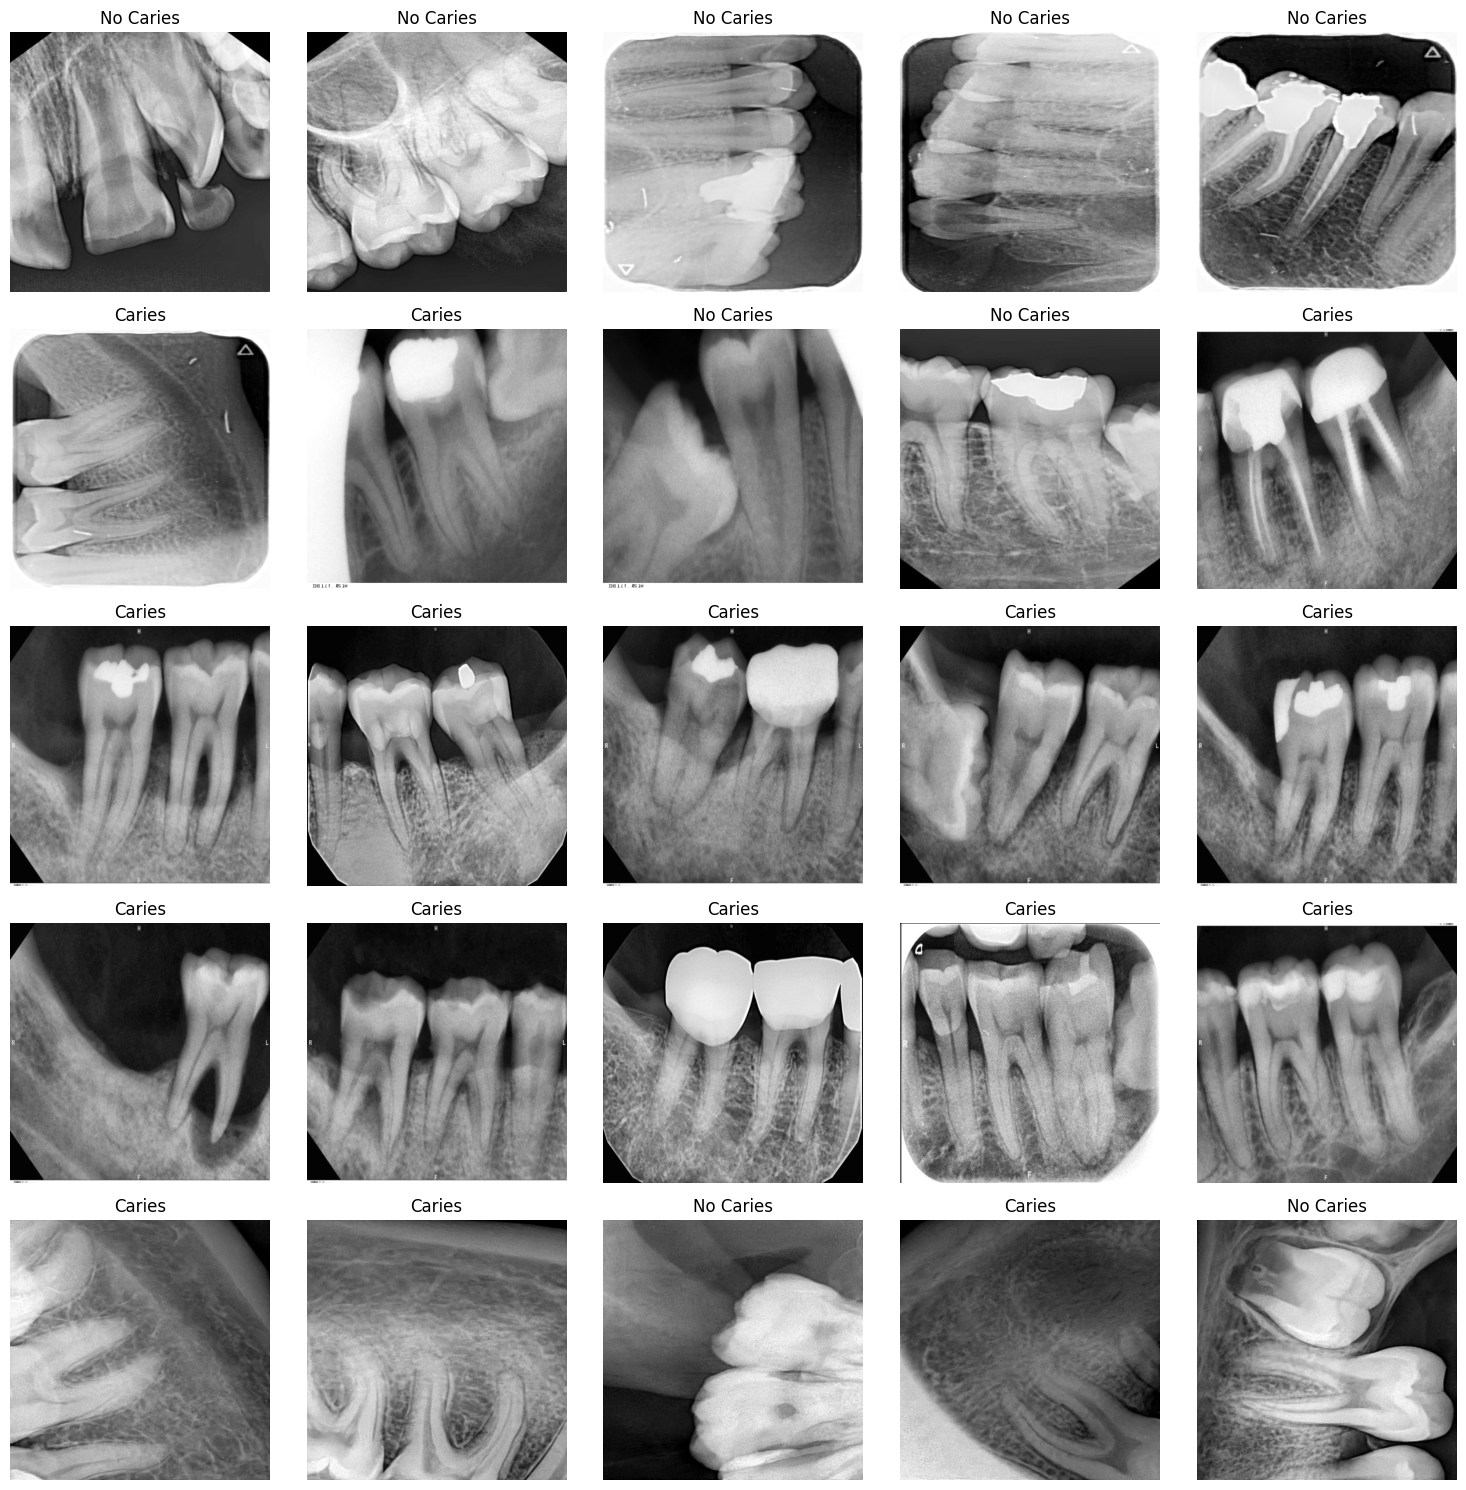

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

def test_on_folder(folder_path, model, device):
    # Apply the same transformations as for the training images
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914], std=[0.2023])
    ])

    model.eval()  # Set model to evaluation mode
    predictions = []  # List to store predictions

    fig, axes = plt.subplots(5, 5, figsize=(15, 15))  # Adjust the size as needed
    axes = axes.flatten()  # Flatten the 2D array to 1D for easier indexing
    img_count = 0

    with torch.no_grad():
        for filename in os.listdir(folder_path):
            if filename.endswith(('.png', '.jpg', '.jpeg')):  # Check for image files
                image_path = os.path.join(folder_path, filename)
                image = Image.open(image_path).convert('L')
                image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
                image_tensor = image_tensor.to(device)

                output = model(image_tensor)
                _, predicted = torch.max(output, 1)
                class_name = 'Caries' if predicted.item() == 1 else 'No Caries'

                # Store the filename and its prediction
                predictions.append((filename, class_name))

                # Display the image and prediction
                if img_count < 25:  # Display only the first 25 images
                    axes[img_count].imshow(image, cmap='gray')
                    axes[img_count].set_title(class_name)
                    axes[img_count].axis('off')
                    img_count += 1

    plt.tight_layout()
    plt.show()

    return predictions

# Specify the folder containing the unseen x-ray images
unseen_folder_path = '/content/drive/MyDrive/Colab Notebooks/Testing-no_carries'  # Change this to your folder path
predictions = test_on_folder(unseen_folder_path, model, device)